In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import h5py
from tqdm import tqdm
import shap  
import matplotlib.pyplot as plt 
import numpy as np
import cmaps
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
# 网页错误处理
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
# 警告信息处理
import warnings
warnings.filterwarnings("ignore")


plt.rc('font', family='Times New Roman')

# 设置全局字体权重为正常
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'normal'

# 设置正常显示负号
plt.rcParams['axes.unicode_minus'] = True

e:\miniconda\envs\liukaiji\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class GEN_Dataset(Dataset):
    def __init__(self, h5_file, variable_names):
        self.h5_file = h5_file
        self.variable_names = variable_names
        self.valid_indices = []
        self._initialize_indices()

    def _initialize_indices(self):
        """初始化有效样本id列表，每个id为一个分组样本（number/i）"""
        with h5py.File(self.h5_file, 'r') as f:
            for number in f.keys():
                for group in f[number].keys():
                    group_path = f"{number}/{group}"
                    # 检查所有变量和spatiotemporal都存在
                    if all(var in f[group_path] for var in self.variable_names) and \
                       'spatiotemporal' in f[group_path]:
                        self.valid_indices.append(group_path)

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, index):
        group_path = self.valid_indices[index]
        with h5py.File(self.h5_file, 'r') as f:
            inputs = []
            for var in self.variable_names:
                data = torch.tensor(f[group_path][var][:], dtype=torch.float32)
                inputs.append(data)
            timespace_matrix = torch.tensor(f[group_path]['spatiotemporal'][:], dtype=torch.float32)
            devflag_raw = f[group_path].attrs['devflag']
            devflag = torch.tensor(float(devflag_raw), dtype=torch.float32)
        return inputs, timespace_matrix, devflag


In [15]:
# 定义残差块，用于ResNet模型构建  
class ResidualBlock3D(nn.Module):  
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):  
        super().__init__()  
        self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)  
        self.bn1 = nn.BatchNorm3d(out_channels)  
        self.relu = nn.ReLU(inplace=True)  
        self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)  
        self.bn2 = nn.BatchNorm3d(out_channels)  
        self.downsample = downsample  

    def forward(self, x):  
        identity = x  
        if self.downsample:  
            identity = self.downsample(x)  
        out = self.relu(self.bn1(self.conv1(x)))  
        out = self.bn2(self.conv2(out))  
        out += identity  
        return self.relu(out)  

# 定义3D ResNet路径  
class ResNet3DPath(nn.Module):  
    def __init__(self, in_channels, layers_config):  
        super().__init__()  
        self.layers = self._make_layers(in_channels, layers_config)  
        
    def _make_layers(self, in_channels, layers_config):  
        layers = []  
        for out_channels, stride in layers_config:  
            downsample = None  
            if stride != 1 or in_channels != out_channels:  
                downsample = nn.Sequential(  
                    nn.Conv3d(in_channels, out_channels, 1, stride=stride, bias=False),  
                    nn.BatchNorm3d(out_channels),  
                )  
            layers.append(ResidualBlock3D(in_channels, out_channels, stride, downsample))  
            in_channels = out_channels  
        layers.append(nn.AdaptiveAvgPool3d((1, 1, 1)))  # 全局平均池化  
        return nn.Sequential(*layers)  

    def forward(self, x):  
        x = self.layers(x)  
        return x.view(x.size(0), -1)  

# 定义多输入3D ResNet模型  
class MultiInputResNet3DModel(nn.Module):  
    def __init__(self, input_configs, gru_input_size=0, gru_hidden_size=0, fc1_output_size=64, use_timespace=False):  
        super().__init__()  
        self.paths = nn.ModuleList([  
            ResNet3DPath(config['input_channels'], config['layers_config']) for config in input_configs  
        ])  
        feature_dim = sum(config['layers_config'][-1][0] for config in input_configs)  
        self.use_timespace = use_timespace  
        if self.use_timespace:  
            self.gru = nn.GRU(input_size=gru_input_size, hidden_size=gru_hidden_size, batch_first=True)  
            feature_dim += gru_hidden_size  
        self.fc1 = nn.Linear(feature_dim, fc1_output_size)  
        self.fc2 = nn.Linear(fc1_output_size, 1)  # 输出通道改为1

    def forward(self, *inputs, timespace=None):  
        features = [path(inp) for path, inp in zip(self.paths, inputs)]  
        if self.use_timespace and timespace is not None:  
            gru_out, _ = self.gru(timespace)  
            timespace_feat = gru_out[:, -1, :]  
            combined_feat = torch.cat(features + [timespace_feat], dim=1)  
        else:  
            combined_feat = torch.cat(features, dim=1)  
        x = self.fc1(combined_feat)
        x = F.relu(x)
        x = self.fc2(x)
        x = torch.sigmoid(x)
        return x.squeeze(1)


# # 1. 定义 "Plain" 块（移除了残差连接）
# # 我们仍然叫它 ResidualBlock3D 以便无缝替换，但它内部已经没有残差连接了
# class ResidualBlock3D(nn.Module):
#     # 注意：__init__ 中移除了 'downsample' 参数
#     def __init__(self, in_channels, out_channels, stride=1):
#         super().__init__()
#         self.conv1 = nn.Conv3d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm3d(out_channels)
#         self.relu = nn.ReLU(inplace=True)
#         self.conv2 = nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
#         self.bn2 = nn.BatchNorm3d(out_channels)
#         # self.downsample = downsample  <-- (已移除)

#     def forward(self, x):
#         # identity = x                  <-- (已移除)
#         # if self.downsample:           <-- (已移除)
#         #     identity = self.downsample(x) <-- (已移除)

#         out = self.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))

#         # out += identity               <-- (这是被移除的核心)
        
#         # 仍然保留最后的ReLU激活，以匹配原始块的输出
#         return self.relu(out)

# # 2. 定义3D路径 (修改 _make_layers 以使用新的块)
# class ResNet3DPath(nn.Module):
#     def __init__(self, in_channels, layers_config):
#         super().__init__()
#         self.layers = self._make_layers(in_channels, layers_config)
        
#     def _make_layers(self, in_channels, layers_config):
#         layers = []
#         for out_channels, stride in layers_config:
#             # downsample = None           <-- (已移除)
#             # if stride != 1 or in_channels != out_channels:  <-- (已移除)
#             #     downsample = nn.Sequential( ... )           <-- (已移除)

#             # 直接调用修改后的块，不再传递 downsample
#             layers.append(ResidualBlock3D(in_channels, out_channels, stride))
#             in_channels = out_channels
            
#         layers.append(nn.AdaptiveAvgPool3d((1, 1, 1))) # 全局平均池化
#         return nn.Sequential(*layers)

#     def forward(self, x):
#         x = self.layers(x)
#         return x.view(x.size(0), -1)

# # 3. 主模型 (这部分代码无需任何更改)
# # 它会自动使用上面修改过的 ResNet3DPath 和 ResidualBlock3D
# class MultiInputResNet3DModel(nn.Module):
#     def __init__(self, input_configs, gru_input_size=0, gru_hidden_size=0, fc1_output_size=64, use_timespace=False):
#         super().__init__()
#         self.paths = nn.ModuleList([
#             ResNet3DPath(config['input_channels'], config['layers_config']) for config in input_configs
#         ])
#         feature_dim = sum(config['layers_config'][-1][0] for config in input_configs)
#         self.use_timespace = use_timespace
#         if self.use_timespace:
#             self.gru = nn.GRU(input_size=gru_input_size, hidden_size=gru_hidden_size, batch_first=True)
#             feature_dim += gru_hidden_size
#         self.fc1 = nn.Linear(feature_dim, fc1_output_size)
#         self.fc2 = nn.Linear(fc1_output_size, 1) # 输出通道改为1

#     def forward(self, *inputs, timespace=None):
#         features = [path(inp) for path, inp in zip(self.paths, inputs)]
#         if self.use_timespace and timespace is not None:
#             gru_out, _ = self.gru(timespace)
#             timespace_feat = gru_out[:, -1, :]
#             combined_feat = torch.cat(features + [timespace_feat], dim=1)
#         else:
#             combined_feat = torch.cat(features, dim=1)
        
#         x = self.fc1(combined_feat)
#         x = F.relu(x)
#         x = self.fc2(x)
#         x = torch.sigmoid(x)
#         return x.squeeze(1)

In [4]:
# 读取训练集并输出第一个样本详细信息
# variable_names = ['ir', "t", "r", "u", "v", "w", "vo", "Vs", "sst", "dgpi"]   # 按实际变量名填写
variable_names = ["u", "vo", "ir", "w", "v", "dgpi","t"]   # 按实际变量名填写
train_dataset_path = "F:/桌面/dataset/tcc_class/train_dataset.h5"  
val_dataset_path = "F:/桌面/dataset/tcc_class/val_dataset.h5"  
test_dataset_path = "F:/桌面/dataset/tcc_class/test_dataset.h5"  

In [5]:
train_dataset = GEN_Dataset(train_dataset_path, variable_names)
val_dataset = GEN_Dataset(val_dataset_path, variable_names)
test_dataset = GEN_Dataset(test_dataset_path, variable_names)

train_loader = DataLoader(train_dataset, batch_size=150, shuffle=True)  
val_loader = DataLoader(val_dataset, batch_size=150, shuffle=True)  


In [6]:
print("训练集样本总数:", len(train_dataset))


train_count_0, train_count_1 = 0, 0
for i in range(len(train_dataset)):
    _, _, devflag = train_dataset[i]
    if devflag.item() == 0:
        train_count_0 += 1
    elif devflag.item() == 1:
        train_count_1 += 1
print(f"训练集 devflag=0 样本数: {train_count_0}")
print(f"训练集 devflag=1 样本数: {train_count_1}")


# 取训练集第一个样本
sample = train_dataset[0]
inputs, timespace_matrix, devflag = sample

print("标签 (devflag):", devflag.item(), "类型:", devflag.dtype)
for i, input_tensor in enumerate(inputs):
    print(f"变量 {variable_names[i]} 的数据形状: {input_tensor.shape}，数据类型: {input_tensor.dtype}")
print("时空信息的形状:", timespace_matrix.shape, "数据类型:", timespace_matrix.dtype)
print("时空信息内容）:\n", timespace_matrix)

训练集样本总数: 8464
训练集 devflag=0 样本数: 3439
训练集 devflag=1 样本数: 5025
标签 (devflag): 1.0 类型: torch.float32
变量 u 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 vo 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 ir 的数据形状: torch.Size([1, 9, 144, 144])，数据类型: torch.float32
变量 w 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 v 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 dgpi 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 t 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
时空信息的形状: torch.Size([9, 6]) 数据类型: torch.float32
时空信息内容）:
 tensor([[ 1.9820e+03,  1.0000e+00,  6.0000e+00,  0.0000e+00,  1.0290e+02,
         -1.2700e+01],
        [ 1.9820e+03,  1.0000e+00,  6.0000e+00,  3.0000e+00,  1.0270e+02,
         -1.2700e+01],
        [ 1.9820e+03,  1.0000e+00,  6.0000e+00,  6.0000e+00,  1.0240e+02,
         -1.2700e+01],
        [ 1.9820e+03,  1.0000e+00,  6.0000e+00,  9.0000e+00,  1.0210e+02,
         -1.2700e+01],
        [ 1.9820e+03,  1.0000e+00,  

In [7]:
print("验证集样本总数:", len(val_dataset))

val_count_0, val_count_1 = 0, 0
for i in range(len(val_dataset)):
    _, _, devflag = val_dataset[i]
    if devflag.item() == 0:
        val_count_0 += 1
    elif devflag.item() == 1:
        val_count_1 += 1
print(f"验证集 devflag=0 样本数: {val_count_0}")
print(f"验证集 devflag=1 样本数: {val_count_1}")

# 取验证集第一个样本
sample = val_dataset[0]
inputs, timespace_matrix, devflag = sample

print("标签 (devflag):", devflag.item(), "类型:", devflag.dtype)
for i, input_tensor in enumerate(inputs):
    print(f"变量 {variable_names[i]} 的数据形状: {input_tensor.shape}，数据类型: {input_tensor.dtype}")
print("时空信息的形状:", timespace_matrix.shape, "数据类型:", timespace_matrix.dtype)
print("时空信息内容）:\n", timespace_matrix)

验证集样本总数: 1159
验证集 devflag=0 样本数: 512
验证集 devflag=1 样本数: 647
标签 (devflag): 1.0 类型: torch.float32
变量 u 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 vo 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 ir 的数据形状: torch.Size([1, 9, 144, 144])，数据类型: torch.float32
变量 w 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 v 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 dgpi 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 t 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
时空信息的形状: torch.Size([9, 6]) 数据类型: torch.float32
时空信息内容）:
 tensor([[ 2.0080e+03,  1.0000e+00,  1.0000e+00,  0.0000e+00,  1.3430e+02,
         -1.6000e+01],
        [ 2.0080e+03,  1.0000e+00,  1.0000e+00,  3.0000e+00,  1.3410e+02,
         -1.6000e+01],
        [ 2.0080e+03,  1.0000e+00,  1.0000e+00,  6.0000e+00,  1.3380e+02,
         -1.6000e+01],
        [ 2.0080e+03,  1.0000e+00,  1.0000e+00,  9.0000e+00,  1.3340e+02,
         -1.5900e+01],
        [ 2.0080e+03,  1.0000e+00,  1.

In [8]:
print("测试集样本总数:", len(test_dataset))

test_count_0, test_count_1 = 0, 0
for i in range(len(test_dataset)):
    _, _, devflag = test_dataset[i]
    if devflag.item() == 0:
        test_count_0 += 1
    elif devflag.item() == 1:
        test_count_1 += 1
print(f"测试集 devflag=0 样本数: {test_count_0}")
print(f"测试集 devflag=1 样本数: {test_count_1}")

# 取测试集第一个样本
sample = test_dataset[0]
inputs, timespace_matrix, devflag = sample

print("标签 (devflag):", devflag.item(), "类型:", devflag.dtype)
for i, input_tensor in enumerate(inputs):
    print(f"变量 {variable_names[i]} 的数据形状: {input_tensor.shape}，数据类型: {input_tensor.dtype}")
print("时空信息的形状:", timespace_matrix.shape, "数据类型:", timespace_matrix.dtype)
print("时空信息内容）:\n", timespace_matrix)

测试集样本总数: 2248
测试集 devflag=0 样本数: 1055
测试集 devflag=1 样本数: 1193
标签 (devflag): 1.0 类型: torch.float32
变量 u 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 vo 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 ir 的数据形状: torch.Size([1, 9, 144, 144])，数据类型: torch.float32
变量 w 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 v 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
变量 dgpi 的数据形状: torch.Size([1, 9, 40, 40])，数据类型: torch.float32
变量 t 的数据形状: torch.Size([3, 9, 40, 40])，数据类型: torch.float32
时空信息的形状: torch.Size([9, 6]) 数据类型: torch.float32
时空信息内容）:
 tensor([[ 2.0120e+03,  1.0000e+00,  6.0000e+00,  1.8000e+01,  4.0600e+01,
         -1.5500e+01],
        [ 2.0120e+03,  1.0000e+00,  6.0000e+00,  2.1000e+01,  4.2200e+01,
         -1.6800e+01],
        [ 2.0120e+03,  1.0000e+00,  7.0000e+00,  0.0000e+00,  4.2700e+01,
         -1.6900e+01],
        [ 2.0120e+03,  1.0000e+00,  7.0000e+00,  3.0000e+00,  4.1000e+01,
         -1.4200e+01],
        [ 2.0120e+03,  1.0000e+00,  

In [16]:
# 变量名到模型配置的映射
config_map = {
    'ir':  {'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    't':   {'input_channels': 3, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'r':   {'input_channels': 3, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'u':   {'input_channels': 3, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'v':   {'input_channels': 3, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'w':   {'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'vo':  {'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'Vs':  {'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'sst': {'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
    'dgpi':{'input_channels': 1, 'layers_config': [(8, 1), (16, 2), (32, 2), (64, 2), (128, 2)]},
}

# 根据变量列表自动生成 input_configs
input_configs = [config_map[var] for var in variable_names if var in config_map]


gru_input_size = 6
gru_hidden_size = 32  
fc1_output_size = 64  

# 初始化模型（注意：不再需要num_classes参数）
model = MultiInputResNet3DModel(
    input_configs=input_configs,
    gru_input_size=gru_input_size,
    gru_hidden_size=gru_hidden_size,
    fc1_output_size=fc1_output_size,
    use_timespace=False
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
# 损失函数和优化器
criterion = nn.BCELoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.8)

num_epochs = 100
patience = 20
best_val_loss = float('inf')
no_improve_count = 0


In [ ]:
for epoch in range(num_epochs):
    # 训练模式
    model.train()
    total_loss, total = 0, 0
    with tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{num_epochs}", leave=False) as train_loader_tqdm:
        for inputs, timespace_matrix, labels in train_loader_tqdm:
            inputs = [x.to(device) for x in inputs]
            timespace_matrix = timespace_matrix.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(*inputs, timespace=timespace_matrix)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
    train_loss = total_loss / total

    # 验证模式
    model.eval()
    val_total_loss, val_total = 0, 0
    with torch.no_grad():
        with tqdm(val_loader, desc=f"Valing Epoch {epoch+1}/{num_epochs}", leave=False) as val_loader_tqdm:
            for inputs, timespace_matrix, labels in val_loader_tqdm:
                inputs = [x.to(device) for x in inputs]
                timespace_matrix = timespace_matrix.to(device)
                labels = labels.to(device)
                outputs = model(*inputs, timespace=timespace_matrix)
                loss = criterion(outputs, labels)
                val_total_loss += loss.item() * labels.size(0)
                val_total += labels.size(0)
    val_loss = val_total_loss / val_total


    # 早停法：保存验证集损失最小的模型
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        no_improve_count = 0
        # 根据变量名生成文件名
        var_str = "_".join(variable_names)
        save_path = f"F:/桌面/dataset/tcc_class/model_base/model_resnet_gru_{var_str}.pth"
        torch.save(model.state_dict(), save_path)


        # 计算指标
        val_preds = []
        val_labels = []
        with torch.no_grad():
            for inputs, timespace_matrix, labels in val_loader:
                inputs = [x.to(device) for x in inputs]
                timespace_matrix = timespace_matrix.to(device)
                labels = labels.to(device)
                outputs = model(*inputs, timespace=timespace_matrix)
                preds = (outputs >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())
        val_preds = np.array(val_preds)
        val_labels = np.array(val_labels)
        accuracy = np.mean(val_preds == val_labels)   # 准确率
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {best_val_loss:.4f}, 准确率(P=0.5)={accuracy:.4f}')

    else:
        no_improve_count += 1
        if no_improve_count >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs.")
            break
    
    scheduler.step(val_loss)


Epoch 1/100, Train Loss: 0.3001, Val Loss: 0.7957, 准确率(P=0.5)=0.6609


Epoch 2/100, Train Loss: 0.2109, Val Loss: 0.3643, 准确率(P=0.5)=0.8783


Early stopping triggered after 22 epochs.


Testing: 100%|██████████| 12/12 [00:02<00:00,  4.10it/s]


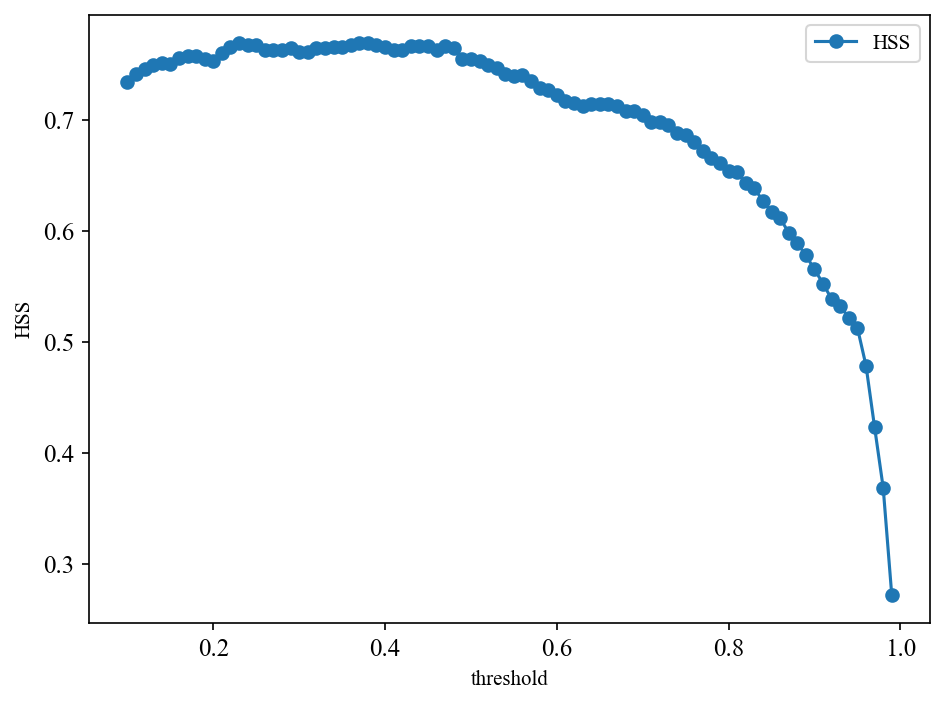

最佳HSS: 0.7701，对应阈值: 0.23
虚警率FAR: 0.1426，检测概率POD: 0.9104，精确率Pre: 0.8897


In [18]:
# 加载测试集
test_dataset_path = "F:/桌面/dataset/tcc_class/test_dataset.h5"
test_dataset = GEN_Dataset(test_dataset_path, variable_names)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

# 加载最佳模型
# 根据变量名生成文件名
var_str = "_".join(variable_names)
model_path = f"F:/桌面/dataset/tcc_class/model_base/model_resnet_nogru_{var_str}.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
# 计算HSS随阈值变化曲线
thresholds = np.arange(0.1, 1.0, 0.01)
hss_list = []
metrics_list = []

with torch.no_grad():
    all_outputs = []
    all_labels = []
    for inputs, timespace_matrix, labels in tqdm(test_loader, desc="Testing"):
        inputs = [x.to(device) for x in inputs]
        timespace_matrix = timespace_matrix.to(device)
        labels = labels.cpu().numpy()
        outputs = model(*inputs, timespace=timespace_matrix).cpu().numpy()
        all_outputs.extend(outputs)
        all_labels.extend(labels)
    all_outputs = np.array(all_outputs)
    all_labels = np.array(all_labels)

f1_list = []
metrics_list = []

for thresh in thresholds: 
    preds = (all_outputs > thresh).astype(int)
    labels = all_labels.astype(int)
    TP = np.sum((preds == 1) & (labels == 1))
    FP = np.sum((preds == 1) & (labels == 0))
    FN = np.sum((preds == 0) & (labels == 1))
    TN = np.sum((preds == 0) & (labels == 0))

    # 按公式计算HSS
    numerator = 2 * (TN * TP - FP * FN)
    denominator = (TN + FN) * (FN + TP) + (TN + FP) * (FP + TP)
    HSS = numerator / denominator if denominator != 0 else 0.0

    POD = TP / (TP + FN) if (TP + FN) != 0 else 0.0 # 检测概率
    FAR = FP / (TN + FP) if (TN + FP) != 0 else 0.0 # 虚警率
    Precision = TP / (TP + FP) if (TP + FP) != 0 else 0.0 # 精确率



    hss_list.append(HSS)
    metrics_list.append((FAR, POD, Precision, HSS))

fig, ax = plt.subplots(dpi=150)
ax.plot(thresholds, hss_list, marker='o', label='HSS')
ax.set_xlabel("threshold")
ax.set_ylabel("HSS")
ax.legend()
ax.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.show()


# 找到最佳HSS及其对应的阈值和指标
best_hss_idx = np.argmax(hss_list)
best_hss_thresh = thresholds[best_hss_idx]
best_FAR, best_POD, best_Precision, best_HSS = metrics_list[best_hss_idx]

print(f"最佳HSS: {best_HSS:.4f}，对应阈值: {best_hss_thresh:.2f}")
print(f"虚警率FAR: {best_FAR:.4f}，检测概率POD: {best_POD:.4f}，精确率Pre: {best_Precision:.4f}")